# Prétraitement des données

L'objectif est de préparer les données avant l'entraînement des modèles de Machine Learning.

Cette étape comprend :
- la suppression des variables inutiles ;
- la séparation des variables explicatives et de la variable cible ;
- le traitement des valeurs manquantes ;
- l'encodage des variables catégorielles ;
- la normalisation des variables numériques ;
- la gestion du déséquilibre des classes.

## Importation des bibliothèques

In [14]:
# On importe les librairies nécessaires pour le preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : la librairie principale pour le Machine Learning
from sklearn.model_selection import train_test_split    # Pour diviser les données
from sklearn.preprocessing import StandardScaler        # Pour normaliser les données
from sklearn.preprocessing import LabelEncoder          # Pour encoder les variables texte
from sklearn.pipeline import Pipeline                   # Pour créer un pipeline propre
from sklearn.compose import ColumnTransformer           # Pour appliquer des transformations
from sklearn.preprocessing import OneHotEncoder         # Pour encoder les catégories
from sklearn.impute import SimpleImputer

# Pour gérer le déséquilibre des classes
from imblearn.over_sampling import RandomOverSampler    # Sur-échantillonnage aléatoire
from imblearn.over_sampling import SMOTE                # SMOTE
from imblearn.under_sampling import RandomUnderSampler  # Sous-échantillonnage

print("✅ Librairies importées avec succès !")

✅ Librairies importées avec succès !


In [15]:
# On recharge le dataset (chaque notebook repart de zéro)
df = pd.read_csv("../data/customer_churn_business_dataset.csv")

print("✅ Dataset chargé !")
print(f"📊 Shape : {df.shape}")
df.head()

✅ Dataset chargé !
📊 Shape : (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [16]:
# Certaines colonnes ne sont pas utiles pour la prédiction :
# - customer_id : identifiant unique du client
# - city : forte cardinalité, supprimée pour simplifier le modèle

# On les supprime
colonnes_a_supprimer = ['customer_id', 'city']
df = df.drop(columns=colonnes_a_supprimer)

print("✅ Colonnes supprimées !")
print(f"📊 Nouvelles dimensions : {df.shape}")
print(f"📋 Colonnes restantes : {list(df.columns)}")

✅ Colonnes supprimées !
📊 Nouvelles dimensions : (10000, 30)
📋 Colonnes restantes : ['gender', 'age', 'country', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


In [17]:
# On sépare le dataset en deux parties :
# X = les features (toutes les colonnes sauf churn)
#     Ce sont les informations qu'on donne au modèle pour qu'il apprenne
# y = la cible (la colonne churn uniquement)
#     C'est ce que le modèle doit prédire

X = df.drop(columns=['churn'])  # Tout sauf churn
y = df['churn']                 # Uniquement churn

print("✅ Séparation features / cible effectuée !")
print(f"📊 X (features) : {X.shape}  ← les données d'entrée")
print(f"🎯 y (cible)    : {y.shape}  ← ce qu'on veut prédire")
print(f"\n📋 Colonnes dans X : {list(X.columns)}")

✅ Séparation features / cible effectuée !
📊 X (features) : (10000, 29)  ← les données d'entrée
🎯 y (cible)    : (10000,)  ← ce qu'on veut prédire

📋 Colonnes dans X : ['gender', 'age', 'country', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count']


## Traitement des valeurs manquantes

L'analyse exploratoire a montré que seule la variable `complaint_type` contient des valeurs manquantes.

Afin de conserver toutes les observations, ces valeurs seront remplacées par une catégorie **"Unknown"** lors du prétraitement.

In [18]:
# Vérification des valeurs manquantes

print(X.isnull().sum()[X.isnull().sum() > 0])

complaint_type    2045
dtype: int64


## Construction du pipeline de prétraitement

Afin d'éviter le **data leakage**, toutes les transformations sont intégrées dans un pipeline.

Le pipeline applique automatiquement :
- l'imputation des valeurs manquantes ;
- la normalisation des variables numériques ;
- l'encodage des variables catégorielles.

Cette approche garantit que les transformations sont apprises uniquement sur les données d'entraînement avant d'être appliquées aux données de test.

In [19]:
# On sépare les colonnes en deux groupes :
# - Colonnes numériques (chiffres) → on va les normaliser
# - Colonnes catégorielles (texte) → on va les encoder

colonnes_numeriques = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
colonnes_categorielles = X.select_dtypes(include=['object']).columns.tolist()

print("📊 Colonnes NUMÉRIQUES (à normaliser) :")
for col in colonnes_numeriques:
    print(f"   - {col}")

print(f"\n📋 Colonnes CATÉGORIELLES (à encoder) :")
for col in colonnes_categorielles:
    print(f"   - {col}")

print(f"\n✅ Total : {len(colonnes_numeriques)} numériques + {len(colonnes_categorielles)} catégorielles = {len(colonnes_numeriques) + len(colonnes_categorielles)} colonnes")

📊 Colonnes NUMÉRIQUES (à normaliser) :
   - age
   - tenure_months
   - monthly_logins
   - weekly_active_days
   - avg_session_time
   - features_used
   - usage_growth_rate
   - last_login_days_ago
   - monthly_fee
   - total_revenue
   - payment_failures
   - support_tickets
   - avg_resolution_time
   - csat_score
   - escalations
   - email_open_rate
   - marketing_click_rate
   - nps_score
   - referral_count

📋 Colonnes CATÉGORIELLES (à encoder) :
   - gender
   - country
   - customer_segment
   - signup_channel
   - contract_type
   - payment_method
   - discount_applied
   - price_increase_last_3m
   - complaint_type
   - survey_response

✅ Total : 19 numériques + 10 catégorielles = 29 colonnes


C:\Users\imen.souidi\AppData\Local\Temp\ipykernel_16200\2853085129.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_categorielles = X.select_dtypes(include=['object']).columns.tolist()


In [20]:
# On divise le dataset en deux parties :
# - Train (80%) : les données qu'on donne au modèle pour qu'il apprenne
# - Test (20%)  : les données qu'on garde de côté pour évaluer le modèle

# IMPORTANT : stratify=y garantit que les proportions de churn 
# sont les mêmes dans le train et le test (90%/10% dans les deux)
# C'est ce qu'on appelle un "stratified split"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Pour avoir toujours les mêmes résultats
    stratify=y          # Très important pour le déséquilibre !
)

print("✅ Split train/test effectué !")
print(f"📊 Train : {X_train.shape[0]} clients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📊 Test  : {X_test.shape[0]} clients ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n🎯 Distribution du churn dans le TRAIN :")
print(f"   Reste (0) : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"   Part  (1) : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\n🎯 Distribution du churn dans le TEST :")
print(f"   Reste (0) : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"   Part  (1) : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

✅ Split train/test effectué !
📊 Train : 8000 clients (80%)
📊 Test  : 2000 clients (20%)

🎯 Distribution du churn dans le TRAIN :
   Reste (0) : 7183 (89.8%)
   Part  (1) : 817 (10.2%)

🎯 Distribution du churn dans le TEST :
   Reste (0) : 1796 (89.8%)
   Part  (1) : 204 (10.2%)


In [21]:
# Un pipeline est une chaîne de transformations appliquées automatiquement
# Il permet d'éviter le data leakage en appliquant les transformations
# uniquement sur les données d'entraînement.

# Pipeline pour les variables numériques
# Les valeurs manquantes (s'il y en avait) seraient remplacées par la médiane,
# puis les variables sont normalisées.

numerique_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les variables catégorielles
# Les valeurs manquantes sont remplacées par "Unknown",
# puis les variables sont encodées avec OneHotEncoder.

categoriel_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Combinaison des deux pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerique_pipeline, colonnes_numeriques),
        ("cat", categoriel_pipeline, colonnes_categorielles)
    ]
)

print("✅ Pipeline de preprocessing créé !")

print("\n📊 Ce que fait le pipeline :")
print("   • Variables numériques : imputation (médiane) + normalisation")
print("   • Variables catégorielles : imputation ('Unknown') + One-Hot Encoding")

✅ Pipeline de preprocessing créé !

📊 Ce que fait le pipeline :
   • Variables numériques : imputation (médiane) + normalisation
   • Variables catégorielles : imputation ('Unknown') + One-Hot Encoding


In [22]:
# On applique le pipeline sur les données train et test
# fit_transform : apprend les transformations SUR le train ET les applique
# transform : applique UNIQUEMENT les transformations apprises sur le train

# IMPORTANT : on fait fit_transform sur le train
# et seulement transform sur le test
# C'est comme ça qu'on évite le data leakage !

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("✅ Preprocessing appliqué !")
print(f"📊 X_train avant : {X_train.shape} → après : {X_train_prepared.shape}")
print(f"📊 X_test avant  : {X_test.shape}  → après : {X_test_prepared.shape}")

✅ Preprocessing appliqué !
📊 X_train avant : (8000, 29) → après : (8000, 51)
📊 X_test avant  : (2000, 29)  → après : (2000, 51)


In [23]:
print("Shape train :", X_train_prepared.shape)
print("Shape test :", X_test_prepared.shape)

print("Valeurs manquantes restantes :", np.isnan(X_train_prepared).sum())

Shape train : (8000, 51)
Shape test : (2000, 51)
Valeurs manquantes restantes : 0


In [24]:
# On va tester 3 techniques pour gérer le déséquilibre 90%/10%
# et comparer leurs effets sur les données

# ---- Technique 1 : Random Over Sampling ----
# On duplique aléatoirement des churners jusqu'à équilibrer les classes
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_prepared, y_train)

# ---- Technique 2 : SMOTE ----
# On crée des churners artificiels (plus intelligent que la duplication)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prepared, y_train)

# ---- Technique 3 : Random Under Sampling ----
# On supprime des non-churners pour équilibrer les classes
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_prepared, y_train)

# On affiche les résultats
print("✅ Techniques de rééquilibrage appliquées !")
print(f"\n📊 AVANT rééquilibrage (train original) :")
print(f"   Reste (0) : {(y_train==0).sum()} clients")
print(f"   Part  (1) : {(y_train==1).sum()} clients")

print(f"\n📊 Après Random Over Sampling :")
print(f"   Reste (0) : {(y_train_ros==0).sum()} clients")
print(f"   Part  (1) : {(y_train_ros==1).sum()} clients")

print(f"\n📊 Après SMOTE :")
print(f"   Reste (0) : {(y_train_smote==0).sum()} clients")
print(f"   Part  (1) : {(y_train_smote==1).sum()} clients")

print(f"\n📊 Après Random Under Sampling :")
print(f"   Reste (0) : {(y_train_rus==0).sum()} clients")
print(f"   Part  (1) : {(y_train_rus==1).sum()} clients")

✅ Techniques de rééquilibrage appliquées !

📊 AVANT rééquilibrage (train original) :
   Reste (0) : 7183 clients
   Part  (1) : 817 clients

📊 Après Random Over Sampling :
   Reste (0) : 7183 clients
   Part  (1) : 7183 clients

📊 Après SMOTE :
   Reste (0) : 7183 clients
   Part  (1) : 7183 clients

📊 Après Random Under Sampling :
   Reste (0) : 817 clients
   Part  (1) : 817 clients


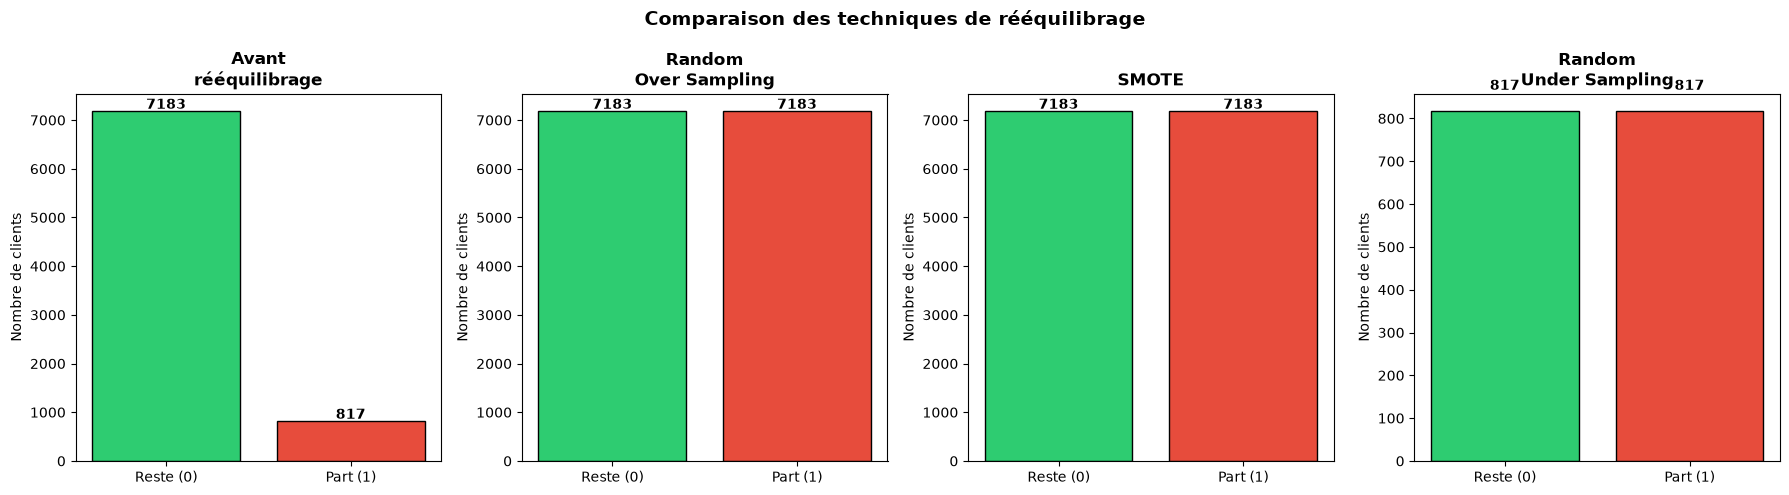

✅ Graphique sauvegardé !


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

datasets = [
    (y_train, "Avant\nrééquilibrage"),
    (y_train_ros, "Random\nOver Sampling"),
    (y_train_smote, "SMOTE"),
    (y_train_rus, "Random\nUnder Sampling")
]

for i, (y, titre) in enumerate(datasets):
    counts = pd.Series(y).value_counts()
    axes[i].bar(['Reste (0)', 'Part (1)'], 
                [counts[0], counts[1]], 
                color=['#2ecc71', '#e74c3c'],
                edgecolor='black')
    axes[i].set_title(titre, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nombre de clients')
    for j, v in enumerate([counts[0], counts[1]]):
        axes[i].text(j, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Comparaison des techniques de rééquilibrage', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Graphique sauvegardé !")

In [26]:
import numpy as np
import joblib

# Sauvegarde des jeux de données prétraités
# Ils seront réutilisés dans le notebook de modélisation.

np.save("../models/X_train_prepared.npy", X_train_prepared)
np.save("../models/X_test_prepared.npy", X_test_prepared)

np.save("../models/X_train_ros.npy", X_train_ros)
np.save("../models/X_train_smote.npy", X_train_smote)
np.save("../models/X_train_rus.npy", X_train_rus)

np.save("../models/y_train.npy", y_train)
np.save("../models/y_test.npy", y_test)

np.save("../models/y_train_ros.npy", y_train_ros)
np.save("../models/y_train_smote.npy", y_train_smote)
np.save("../models/y_train_rus.npy", y_train_rus)

# Sauvegarde du pipeline de prétraitement
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("✅ Toutes les données ont été sauvegardées avec succès !")

print("\n📁 Fichiers enregistrés dans le dossier models/ :")
print("   • X_train_prepared.npy  → Jeu d'entraînement prétraité")
print("   • X_test_prepared.npy   → Jeu de test prétraité")
print("   • X_train_ros.npy       → Jeu d'entraînement avec Random Over Sampling")
print("   • X_train_smote.npy     → Jeu d'entraînement avec SMOTE")
print("   • X_train_rus.npy       → Jeu d'entraînement avec Random Under Sampling")
print("   • y_train.npy           → Variable cible (train)")
print("   • y_test.npy            → Variable cible (test)")
print("   • y_train_ros.npy       → Variable cible après ROS")
print("   • y_train_smote.npy     → Variable cible après SMOTE")
print("   • y_train_rus.npy       → Variable cible après RUS")
print("   • preprocessor.pkl      → Pipeline de prétraitement")

✅ Toutes les données ont été sauvegardées avec succès !

📁 Fichiers enregistrés dans le dossier models/ :
   • X_train_prepared.npy  → Jeu d'entraînement prétraité
   • X_test_prepared.npy   → Jeu de test prétraité
   • X_train_ros.npy       → Jeu d'entraînement avec Random Over Sampling
   • X_train_smote.npy     → Jeu d'entraînement avec SMOTE
   • X_train_rus.npy       → Jeu d'entraînement avec Random Under Sampling
   • y_train.npy           → Variable cible (train)
   • y_test.npy            → Variable cible (test)
   • y_train_ros.npy       → Variable cible après ROS
   • y_train_smote.npy     → Variable cible après SMOTE
   • y_train_rus.npy       → Variable cible après RUS
   • preprocessor.pkl      → Pipeline de prétraitement


# Conclusion

Les données ont été correctement préparées pour la phase de modélisation.

Les principales étapes réalisées sont :

- suppression des variables inutiles ;
- traitement des valeurs manquantes ;
- normalisation des variables numériques ;
- encodage des variables catégorielles ;
- gestion du déséquilibre des classes ;
- sauvegarde des jeux de données prétraités et du pipeline.

Ces données seront utilisées dans le notebook suivant consacré à l'entraînement et à l'évaluation des modèles de Machine Learning.